In [2]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom
from array_despike import array_despike
from gaussian_fit import fit_gaussian

本文档用于整理OⅠ和Si IV的拟合

In [ ]:
#因为在Si IV上，活动区爆发前其实还有一些小的喷流一直在，因此还是打算用OⅠ线来定标
#并且发现在整条光谱线上都有较大的

Text(0.5, 1.0, 'IRIS SJI 1400 Å at 21:04:35')

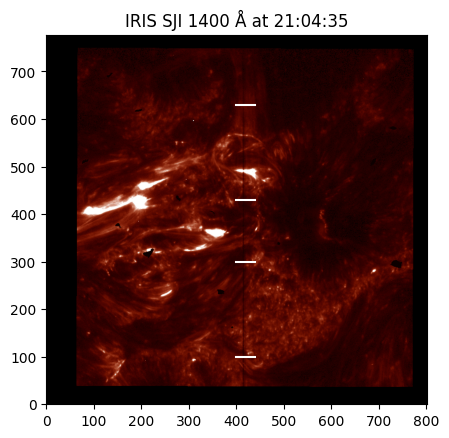

In [6]:
rsm_1400=fits.open(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_SJI_1400_t000.fits')
sji1400=rsm_1400[0].data
new_map=np.log(sji1400[785,:,:]+201)#对应时间21：04：35
plt.imshow(new_map,origin='lower',cmap='irissji1400',vmin=5.3,vmax=5.8)
plt.plot([400, 440], [100, 100], linestyle='-', color='white')
plt.plot([400, 440], [300, 300], linestyle='-', color='white')
plt.plot([400, 440], [430, 430], linestyle='-', color='white')
plt.plot([400, 440], [630, 630], linestyle='-', color='white')
plt.title('IRIS SJI 1400 Å at 21:04:35')
#上面两个白线中间是用于积分计算的活动区
#下面两条白线的区域是积分计算的“宁静区”

bright pass 0: replaced 574 pixels
bright pass 1: replaced 95 pixels
bright pass 2: replaced 35 pixels
bright pass 3: replaced 19 pixels
bright pass 4: replaced 4 pixels
bright pass 5: replaced 0 pixels
dark pass 0: replaced 10 pixels
dark pass 1: replaced 2 pixels
dark pass 2: replaced 0 pixels
有多少个NaN值 1293
1354.9629103618772 1356.520510375789
拟合得到的OI多普勒速度为 13.931715752585038 km/s
拟合得到的CI多普勒速度为 17.80981000334459 km/s


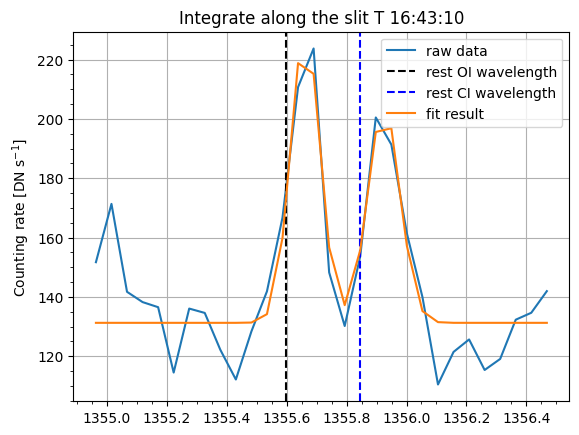

In [13]:
#读取数据
file_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\*.fits')
rsm=fits.open(file_list[16])
spectrum=rsm[2].data[4,:,:]#rsm[2]对应OⅠ，data[4,:,:]对应八步扫描中目标狭缝在我想要的位置
exptime=rsm[0].header['EXPTIME']
from array_despike import array_despike
#IRIS会将一些NaN设置为-200
#去除宇宙线的卷积时应该忽略掉这些值
valid_mask = (
    np.isfinite(spectrum)
    & (spectrum != -200)
)
#去除宇宙线（由IDL的array_despike.pro转写而来
spectrum_clean, info = array_despike(
    spectrum,
    sigma=8.0,
    threshold=6.0,
    itmax=20,
    no_low=False,
    valid_mask=valid_mask,
    return_info=True,
    verbose=True,
)

#生成波长数组
wave_x=np.arange(rsm[2].header['CRVAL1'],rsm[2].header['CRVAL1']+rsm[2].header['CDELT1']*rsm[2].header['NAXIS1'],
                 rsm[2].header['CDELT1'])
#CRVAL1=1346.91531, CDELT1=0.05192, NAXIS1=203
#选取“宁静区”
selected = spectrum_clean[100:300, :]
selected = selected.astype(float)
print('有多少个NaN值',np.count_nonzero(selected == -200))
selected[selected == -200] = np.nan
wave_y1 = np.nansum(selected, axis=0)
wave_y1=wave_y1/exptime

start_point,end_point=155,185
#分别对应波长1354.9629103618772 1356.520510375789
plt.plot(wave_x[start_point:end_point],wave_y1[start_point:end_point],label='raw data')
plt.axvline(x=1355.599,linestyle='--',color='black',label='rest OI wavelength')
plt.axvline(x=1355.844,linestyle='--',color='blue',label='rest CI wavelength')
plt.ylabel(r"Counting rate [DN s$^{-1}$]")
plt.title('Integrate along the slit T 16:43:10')
plt.legend()

#双高斯同时拟合O和C
from gaussian_fit import fit_double_gaussian
result=fit_double_gaussian(wave_x[start_point:end_point],wave_y1[start_point:end_point])
print('拟合得到的OI多普勒速度为',(result['center1']-1355.599)/1355.599*3e5,'km/s')
print('拟合得到的CI多普勒速度为',(result['center2']-1355.844)/1355.844*3e5,'km/s')
plt.plot(wave_x[start_point:end_point],result['yfit'],label='fit result')
plt.legend()
plt.minorticks_on()
plt.grid()